<h3 style="color:#6FA8DC; font-weight:bold">01 — Feature Engineering Introduction</h3>

<h5 style="color:#78B89A; font-weight:bold;">Understanding how raw data becomes useful for Machine Learning</h5>

Feature Engineering is one of the most important stages of a Machine Learning project.

A Machine Learning algorithm cannot directly understand every type of real-world data. Raw data may contain:

- Missing values
- Text or categorical values
- Different numerical ranges
- Outliers
- Irrelevant columns
- Unstructured data such as images, text, and audio

Feature Engineering helps us convert this raw data into a clean, meaningful, and model-friendly form.

### Simple definition

> **Feature Engineering is the process of creating, transforming, selecting, or extracting useful features from raw data to improve Machine Learning performance.**

<div style="border-top:black 2px solid"></div>

# 1. What is a Feature?

A **feature** is an input variable or column that provides information to a Machine Learning model.

Suppose we want to predict house prices.

| Area | Bedrooms | Location | House Age | Price |
|---:|---:|---|---:|---:|
| 1200 | 2 | Delhi | 10 | 65 lakh |
| 1800 | 3 | Noida | 5 | 95 lakh |
| 900 | 2 | Delhi | 20 | 45 lakh |

Here:

- `Area` → Feature
- `Bedrooms` → Feature
- `Location` → Feature
- `House Age` → Feature
- `Price` → Target/Output

### Feature vs Target

| Term | Meaning |
|---|---|
| Feature / Input / X | Information given to the model |
| Target / Output / y | Value the model tries to predict |

For example, in a house-price prediction problem:

```text
X = Area, Bedrooms, Location, House Age
y = Price
```

# 2. Why do we need Feature Engineering?

Raw data is usually not ready to be directly given to a Machine Learning algorithm.

### Example: E-commerce customer prediction

Suppose we want to predict whether a customer will purchase a product.

Raw data:

| Age | City | Total Spending | Number of Orders | Last Purchase |
|---:|---|---:|---:|---|
| 22 | Delhi | 5000 | 5 | 10 days ago |
| 35 | Mumbai | 24000 | 3 | 2 days ago |

A model may learn better if we create meaningful features such as:

- Average Order Value
- Days Since Last Purchase
- Customer Age Group
- Repeat Customer Flag

### Feature Engineering helps us to:

1. Handle missing values.
2. Convert categorical data into numerical form.
3. Reduce the effect of outliers.
4. Bring numerical features to comparable scales.
5. Create meaningful new features.
6. Remove irrelevant or redundant features.
7. Convert text, images, and audio into numerical representations.
8. Improve model performance and reduce unnecessary complexity.

# 3. Feature Engineering in the Machine Learning Workflow

The first diagram shows where Feature Engineering fits into the complete Machine Learning workflow.

Feature Engineering is mainly performed during **Data Preparation**.

It happens before the final model training stage.
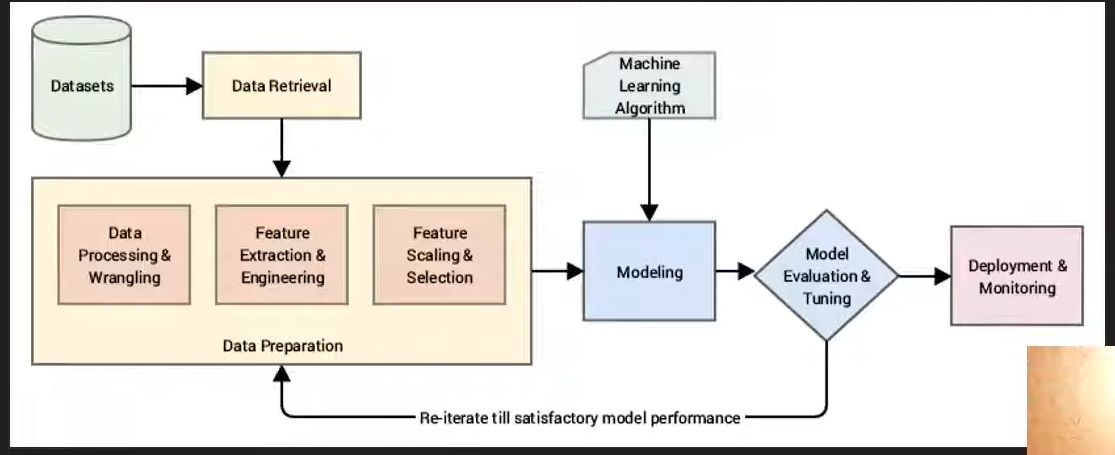

![Machine Learning Workflow](attachment:workflow.png)

### Understanding the workflow

1. **Dataset** — Raw data is collected.
2. **Data Retrieval** — Data is loaded from files, databases, APIs, etc.
3. **Data Processing and Wrangling** — Data is cleaned and organised.
4. **Feature Extraction and Engineering** — Useful features are created or transformed.
5. **Feature Scaling and Selection** — Features are scaled and useful columns are selected.
6. **Modelling** — The algorithm learns patterns.
7. **Model Evaluation and Tuning** — Model performance is checked.
8. **Deployment and Monitoring** — The model is used in the real world.

If the model does not perform satisfactorily, we may return to Data Preparation and improve our features.

<div style="border-top:black 2px solid"></div>

# 4. Main Areas of Feature Engineering

The second uploaded diagram divides Feature Engineering into four major areas:

1. **Feature Transformation**
2. **Feature Construction**
3. **Feature Selection**
4. **Feature Extraction**

Feature Transformation includes:

- Missing Value Imputation
- Handling Categorical Features
- Outlier Detection
- Feature Scaling
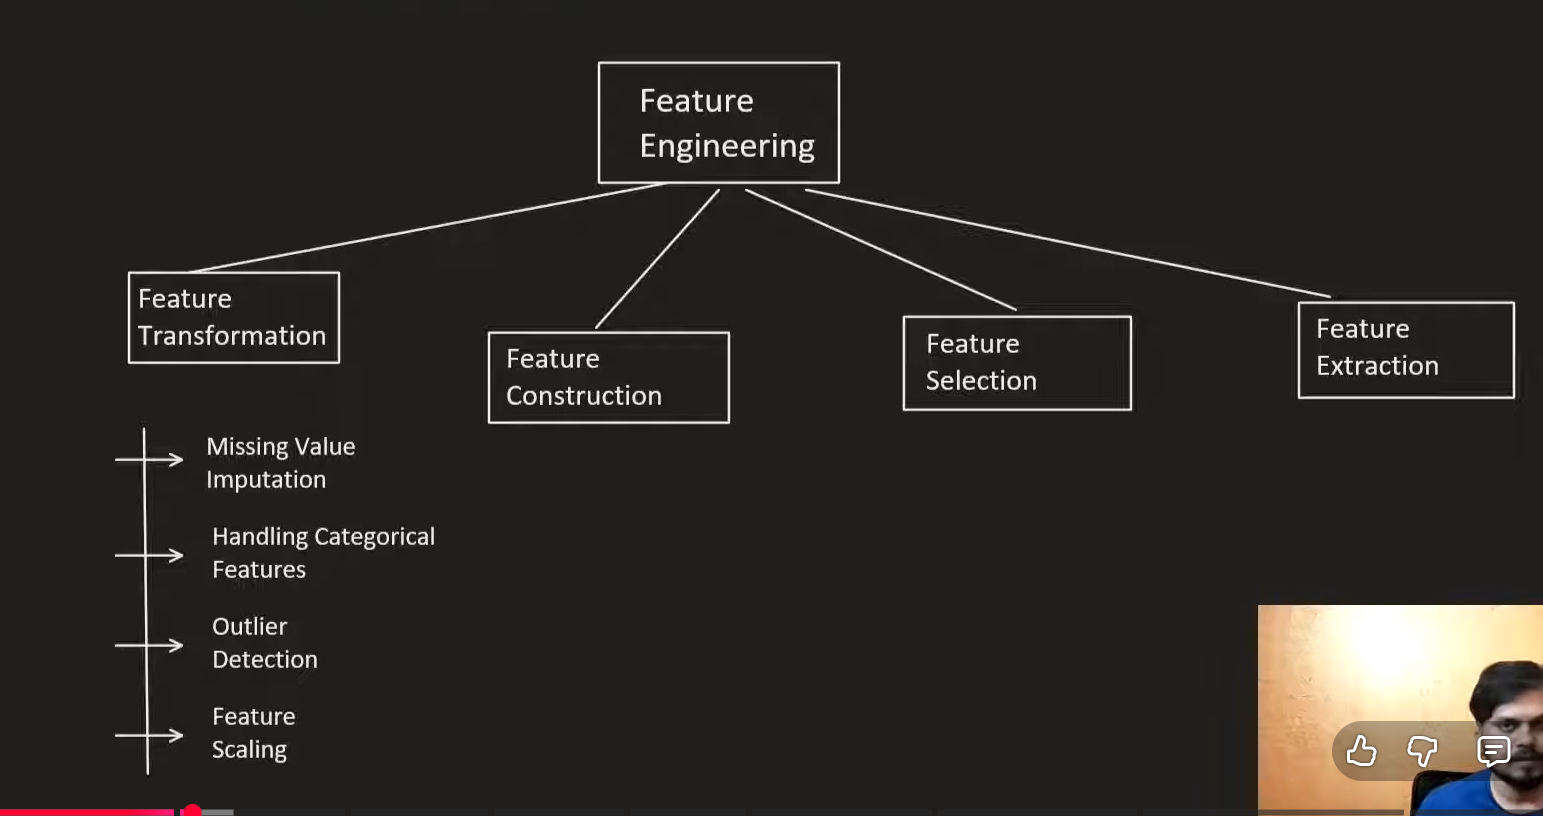

![Feature Engineering Overview](attachment:feature_engineering_overview.png)

# 1. Feature Transformation

Feature Transformation means changing the representation, format, or scale of existing features.

We do not necessarily create a completely new concept. Instead, we make the existing data more suitable for Machine Learning.

The major parts are:

### 1.1 Missing Values Imputation

### 1.2 Handling Categorical Values

### 1.3 Outlier Detection

### 1.4 Feature Scaling

## 1.1 Missing Values Imputation

### What are missing values?

Missing values occur when information is unavailable for one or more observations.

Example:

| Age | Salary | City |
|---:|---:|---|
| 21 | 40000 | Delhi |
| NaN | 50000 | Noida |
| 24 | NaN | Delhi |

`NaN` means that the value is missing.

### Why are missing values a problem?

Many Machine Learning algorithms cannot directly process missing values.

They can also:

- Reduce usable information.
- Cause errors during model training.
- Distort statistical calculations.
- Produce biased predictions if handled incorrectly.

### What is imputation?

**Imputation** means filling missing values with appropriate replacement values.

Common techniques:

1. Mean imputation
2. Median imputation
3. Mode imputation
4. Constant-value imputation
5. Forward fill
6. Backward fill
7. Model-based imputation

### Real-life ML example

In a house-price dataset, the age of some houses may be missing.

We may replace missing values with the median house age because the median is less affected by extreme values than the mean.

In [ ]:
import pandas as pd
import numpy as np

data = pd.DataFrame({
    'Age': [21, 22, np.nan, 24, 25],
    'Salary': [40000, 50000, 45000, np.nan, 60000],
    'City': ['Delhi', 'Noida', 'Delhi', np.nan, 'Gurgaon']
})

data

In [ ]:
# Numerical column: median imputation
data['Age'] = data['Age'].fillna(data['Age'].median())

# Numerical column: mean imputation
data['Salary'] = data['Salary'].fillna(data['Salary'].mean())

# Categorical column: mode imputation
data['City'] = data['City'].fillna(data['City'].mode()[0])

data

### Important rule

Do not blindly replace every missing value with zero.

For example:

- Missing salary does not necessarily mean salary is zero.
- Missing age does not mean age is zero.
- Missing city does not mean the person belongs to a numerical category called zero.

The imputation method should depend on the meaning of the feature.

## 1.2 Handling Categorical Values

### What are categorical features?

Categorical features contain labels or groups rather than continuous numerical values.

Examples:

- Gender
- City
- Department
- Payment Method
- Blood Group
- Education Level
- Employment Type

Example:

| Gender | City | Payment Method |
|---|---|---|
| Male | Delhi | UPI |
| Female | Mumbai | Card |
| Male | Delhi | Cash |

Most Machine Learning algorithms require numerical inputs, so categorical data often needs to be encoded.

### Common techniques

1. Label Encoding
2. Ordinal Encoding
3. One-Hot Encoding
4. Frequency Encoding
5. Target Encoding

### Real-life ML example

A loan approval model may contain:

```text
Employment Type = Salaried, Self-employed, Student
```

The model cannot directly perform mathematical operations on these text labels. We convert them into a suitable numerical representation.

In [ ]:
df = pd.DataFrame({
    'City': ['Delhi', 'Mumbai', 'Delhi', 'Pune']
})

pd.get_dummies(df, columns=['City'], dtype=int)

### One-Hot Encoding

One-hot encoding creates a separate binary column for each category.

Example:

| City | City_Delhi | City_Mumbai | City_Pune |
|---|---:|---:|---:|
| Delhi | 1 | 0 | 0 |
| Mumbai | 0 | 1 | 0 |
| Delhi | 1 | 0 | 0 |
| Pune | 0 | 0 | 1 |

- `1` means the row belongs to that category.
- `0` means it does not belong to that category.

### Important warning

For nominal categories such as city or colour, arbitrary numbering can create a false order.

```text
Delhi = 1
Mumbai = 2
Pune = 3
```

This may incorrectly suggest that Pune is greater than Mumbai.

One-hot encoding is often more suitable for nominal categories.

## 1.3 Outlier Detection

### What is an outlier?

An outlier is an observation that is unusually far away from the majority of the data.

Example:

```text
25000, 28000, 30000, 32000, 35000, 500000
```

The value `500000` may be an outlier compared with the other salaries.

### Real-life examples

- A transaction of ₹10,00,000 when most transactions are below ₹5,000.
- A house with an unusually high price.
- A sensor showing an impossible temperature.
- A student score of 950 when the exam maximum is 100.

### Why can outliers be harmful?

Outliers may:

- Distort the mean.
- Increase standard deviation.
- Affect linear regression.
- Influence distance-based algorithms.
- Make graphs difficult to interpret.

### Common detection methods

1. Box plot
2. IQR method
3. Z-score
4. Scatter plot
5. Domain-based rules

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

salary_data = pd.DataFrame({
    'Salary': [25000, 28000, 30000, 32000, 35000, 500000]
})

sns.boxplot(data=salary_data, x='Salary')
plt.title('Salary Outlier Example')
plt.show()

### IQR method

IQR stands for **Interquartile Range**.

\[
IQR = Q3 - Q1
\]

Lower boundary:

\[
Q1 - 1.5 \times IQR
\]

Upper boundary:

\[
Q3 + 1.5 \times IQR
\]

Values outside these boundaries are commonly treated as possible outliers.

### Important point

An outlier is not always an error.

A very high salary may be a valid observation. Before removing an outlier, understand the domain and the reason behind the value.

## 1.4 Feature Scaling

### What is Feature Scaling?

Feature Scaling means bringing numerical features to a comparable scale.

Suppose a dataset contains:

- Age: 18 to 70
- Salary: 20,000 to 2,00,000
- Experience: 0 to 30

Salary has much larger numerical values than age or experience.

Some algorithms may give excessive importance to salary because of its scale.

### Algorithms that commonly benefit from scaling

- K-Nearest Neighbours
- K-Means Clustering
- Support Vector Machines
- Logistic Regression
- Neural Networks
- Principal Component Analysis

Tree-based algorithms generally do not require scaling in the same way.

### Main types

1. Standardisation
2. Min-Max Scaling
3. Robust Scaling
4. MaxAbs Scaling
5. Normalisation

<div style="border-top:black 2px solid"></div>

# 2. Feature Construction

### What is Feature Construction?

Feature Construction means creating new features from existing features using:

- Arithmetic operations
- Domain knowledge
- Logical conditions
- Combining multiple columns
- Date and time information

It is also called **Feature Creation**.

### Example

Suppose we have:

- Date of Birth
- Current Date

We can create:

```text
Age = Current Date - Date of Birth
```

Age may be more useful to a model than the raw date of birth.

### Real-life ML examples

#### E-commerce

Existing features:

- Total Spending
- Number of Orders

New feature:

\[
Average\ Order\ Value = \frac{Total\ Spending}{Number\ of\ Orders}
\]

#### Banking

Existing features:

- Monthly Income
- Monthly Expenses

New feature:

\[
Savings\ Ratio = \frac{Income - Expenses}{Income}
\]

#### Website analytics

Existing features:

- Session Duration
- Pages Visited

New feature:

```text
Average Time per Page = Session Duration / Pages Visited
```

#### College placement prediction

Existing features:

- Attendance
- DSA Score
- Projects Completed
- Coding Contest Participation

New feature:

```text
Preparation Score = weighted combination of these values
```

Feature Construction can expose relationships that were hidden in the original columns.

In [ ]:
student = pd.DataFrame({
    'Study_Hours': [2, 4, 6, 8],
    'Practice_Questions': [10, 25, 40, 60],
    'Mock_Test_Score': [45, 60, 75, 90]
})

student['Questions_Per_Hour'] = (
    student['Practice_Questions'] / student['Study_Hours']
)

student['Preparation_Index'] = (
    0.3 * student['Study_Hours'] +
    0.3 * student['Questions_Per_Hour'] +
    0.4 * student['Mock_Test_Score']
)

student

<div style="border-top:black 2px solid"></div>

# 3. Feature Selection

### What is Feature Selection?

Feature Selection means selecting the most useful features from the dataset and removing:

- Irrelevant features
- Redundant features
- Noisy features
- Constant or almost-constant features

### Example

Suppose we are predicting house prices.

Available columns:

- Area
- Bedrooms
- Location
- House Age
- Owner's Favourite Colour
- Random ID
- Unrelated Text

Some columns may not help the model.

Feature Selection attempts to retain useful information and remove unnecessary information.

### Benefits

- Reduces model complexity.
- Can improve training speed.
- May reduce overfitting.
- Makes the model easier to interpret.
- Reduces memory usage.
- Removes noise and redundant information.

### Main methods

#### 1. Filter Methods

Use statistical properties before model training.

Examples:

- Correlation
- Chi-square test
- Mutual information
- Variance Threshold

#### 2. Wrapper Methods

Try different feature subsets by repeatedly training and evaluating a model.

Examples:

- Forward Selection
- Backward Elimination
- Recursive Feature Elimination (RFE)

#### 3. Embedded Methods

Feature selection happens during model training.

Examples:

- Lasso Regression
- Decision Tree Feature Importance
- Random Forest Feature Importance

In [ ]:
from sklearn.feature_selection import VarianceThreshold

sample_features = pd.DataFrame({
    'Age': [20, 21, 22, 23, 24],
    'Constant_Column': [1, 1, 1, 1, 1],
    'Score': [50, 60, 55, 70, 80]
})

selector = VarianceThreshold(threshold=0)

selected = selector.fit_transform(sample_features)

pd.DataFrame(
    selected,
    columns=sample_features.columns[selector.get_support()]
)

### Feature Selection vs Feature Construction

| Feature Selection | Feature Construction |
|---|---|
| Selects existing features | Creates new features |
| Removes unnecessary columns | Combines or transforms existing information |
| Example: remove `Random_ID` | Example: create `Average_Order_Value` |
| Reduces the feature set | Improves the representation of information |

<div style="border-top:black 2px solid"></div>

# 4. Feature Extraction

### What is Feature Extraction?

Feature Extraction means converting original data into a new, usually smaller or more useful set of features.

The new features may not directly correspond to the original columns.

It is especially useful for:

- Text
- Images
- Audio
- High-dimensional numerical data
- Data containing many correlated variables

### Real-life examples

#### Image Classification

An image may contain thousands of pixel values.

Feature extraction can produce:

- Edges
- Shapes
- Textures
- Image embeddings

#### Text Classification

A document contains words and sentences.

Feature extraction can convert text into:

- Bag-of-Words vectors
- TF-IDF vectors
- Word embeddings
- Sentence embeddings

#### Audio Classification

An audio recording can be converted into:

- MFCC features
- Spectral Centroid
- Zero-Crossing Rate
- Chroma features

These features can help classify traffic, speech, rain, music, and other sounds.

#### Numerical Data

PCA can convert many correlated numerical features into a smaller number of principal components.

## Feature Extraction using PCA

Suppose a dataset contains:

- Height
- Weight
- BMI
- Waist Size
- Body Fat Percentage

These features may be correlated.

Principal Component Analysis, or **PCA**, transforms them into a smaller number of components while preserving as much important variation as possible.

### Important distinction

Feature Extraction is not simply deleting columns.

It creates a new representation of the data.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

iris = load_iris()

X = iris.data

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2']
)

pca_df.head()

In [ ]:
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue=iris.target
)

plt.title('Iris Dataset after PCA Feature Extraction')
plt.show()

<div style="border-top:black 2px solid"></div>

# 5. Complete Real-Life Example

Imagine we want to predict whether an online customer will purchase a product.

### Raw features

- Age
- City
- Session Time
- Pages Visited
- Income
- Last Purchase Date
- Customer ID
- Review Text

### Step 1 — Missing Value Imputation

Fill missing income or city values using a suitable strategy.

### Step 2 — Handling Categorical Values

Convert city into one-hot encoded columns.

### Step 3 — Outlier Detection

Check for impossible session times, such as 999999 minutes.

### Step 4 — Feature Scaling

Scale income, session time, and pages visited if the selected algorithm needs scaling.

### Step 5 — Feature Construction

Create:

- Pages per minute
- Days since last purchase
- Average spending per order
- Repeat customer flag

### Step 6 — Feature Selection

Remove:

- Random customer ID
- Irrelevant columns
- Duplicate information

### Step 7 — Feature Extraction

Convert review text into TF-IDF vectors or embeddings.

Now the dataset is more useful for Machine Learning.

<div style="border-top:black 2px solid"></div>

# 6. Important Practical Rules

1. Understand the meaning of every column before transforming it.
2. Do not remove outliers without checking whether they are valid.
3. Do not assign arbitrary numerical labels to nominal categories.
4. Fit preprocessing steps on training data, not on the complete dataset.
5. Avoid data leakage.
6. Create features using information available at prediction time.
7. Keep a record of every transformation.
8. Do not create hundreds of random features without a reason.
9. Evaluate whether a new feature actually improves model performance.
10. Domain knowledge is extremely valuable in Feature Engineering.

### What is Data Leakage?

Data leakage occurs when information that would not be available at prediction time enters the training process.

Example:

To predict whether a customer will default on a loan, using:

```text
Recovery Amount After Default
```

would leak future information into the model.

The model may show excellent training performance but fail in the real world.

# 7. Final Comparison

| Area | Meaning | Example |
|---|---|---|
| Feature Transformation | Changes existing feature representation | Imputation, encoding, scaling |
| Feature Construction | Creates new meaningful features | Average Order Value |
| Feature Selection | Selects useful existing features | Removing Random ID |
| Feature Extraction | Converts data into a new representation | PCA, TF-IDF, MFCC |

### Final Memory Trick

**Transform → Construct → Select → Extract**

- **Transform** existing data.
- **Construct** new information.
- **Select** useful columns.
- **Extract** a new representation.

### One-line takeaway

> **Feature Engineering converts raw data into clean, meaningful, useful, and model-friendly inputs.**

<div style="border-top:black 2px solid"></div>

## Upcoming Topics

1. Missing Values Imputation
2. Handling Categorical Values
3. Outlier Detection
4. Feature Scaling
5. Feature Construction
6. Feature Selection
7. Feature Extraction